# ✉ Reddit 커뮤니티 데이터 기반 SNS 트렌드 분석

**팀원:** 최호림 · 전재영  
**기간:** 2026.05.06 ~ 2026.06.01

| 단계 | 담당 |
|------|------|
| 환경 세팅 | 공통 |
| 데이터 수집 | 전재영 |
| 텍스트 전처리 | **최호림** |
| 감성 분석 | 전재영 |
| 토픽 모델링 | **최호림** |
| 트렌드 분석 + 시각화 | 전재영 |
| FastAPI 배포 | **최호림** |

---
## STEP1. 기획 배경 및 목적

> Reddit을 선택한 이유는 단순한 반응을 넘어 심층적인 토론과 의견이 담긴 플랫폼이기 때문입니다. 특히 technology, MachineLearning, datascience 같은 기술 서브레딧은 AI 관련 이슈가 발생했을 때 뉴스보다 빠르게 반응하는 특성이 있습니다.
>
> 이 프로젝트의 목표 3가지  

*   첫째, AI와 ChatGPT 같은 기술 키워드가 시간에 따라 어떻게 변화하는지 추적합니다.
*   둘째, 커뮤니티 감성이 어떻게 분포되어 있는지 파악합니다.
*   셋째, 분석 결과를 FastAPI로 제공해 누구나 조회할 수 있는 시스템을 구축합니다.

---
## STEP2. 데이터 수집

Reddit API를 활용해 데이터를 수집했습니다.
>
> Colab 환경에서 Reddit JSON 요청 시 403 Forbidden 오류가 발생해, 로컬 환경에서 직접 수집했습니다.
>
> **수집 대상:** technology, MachineLearning, ChatGPT, AI, programming, datascience, computers, artificial, gadgets, Futurology — 총 10개 서브레딧
>
> **수집 결과:** 총 **1,006개** 게시글 (제목, 본문, 업보트 수, 댓글 수, 작성 시간 포함)

In [ ]:
#패키지 설치
!pip install pandas requests

In [ ]:
#라이브러리
import requests
import pandas as pd
from datetime import datetime
import time

In [ ]:
#데이터 수집한 CSV 파일 불러오기
from google.colab import files

uploaded = files.upload()

Saving reddit_trend_data.csv to reddit_trend_data.csv


In [ ]:
#파일 확인하기
reddit_df = pd.read_csv("reddit_trend_data.csv")
reddit_df.head()

,post_id,subreddit,category,title,body,score,upvote_ratio,num_comments,created_utc,url,text
0,1t78j3w,technology,hot,Tesla is recalling its cheaper Cybertruck beca...,NaN,1399,0.97,191,2026-05-08 22:49:34,https://www.reddit.com/r/technology/comments/1...,Tesla is recalling its cheaper Cybertruck beca...
1,1t76q5a,technology,hot,AI data center bans are rapidly multiplying ac...,NaN,1047,0.98,50,2026-05-08 21:39:07,https://www.reddit.com/r/technology/comments/1...,AI data center bans are rapidly multiplying ac...
2,1t74w7g,technology,hot,Sierra Club report: Texas coal plants draining...,NaN,1291,0.97,69,2026-05-08 20:15:58,https://www.reddit.com/r/technology/comments/1...,Sierra Club report: Texas coal plants draining...
3,1t6tq7t,technology,hot,The world is trying to log off U.S. tech,NaN,5515,0.96,514,2026-05-08 10:29:30,https://www.reddit.com/r/technology/comments/1...,The world is trying to log off U.S. tech
4,1t75ntg,technology,hot,Claude Code's creator is sick of the phrase 'v...,NaN,599,0.79,743,2026-05-08 20:52:39,https://www.reddit.com/r/technology/comments/1...,Claude Code's creator is sick of the phrase 'v...


In [ ]:
#데이터 개수 확인
print("전체 데이터 개수:", len(reddit_df))

전체 데이터 개수: 1006


In [ ]:
#중복 제거 확인
print("전체 데이터:", len(reddit_df))
print("고유 post_id:", reddit_df["post_id"].nunique())

전체 데이터: 1006
고유 post_id: 1006


---
## STEP 3. 텍스트 전처리

> 다음으로 텍스트 전처리 과정을 설명하겠습니다.
>
> Reddit 게시글에는 URL, r/subreddit, u/user, 마크다운, HTML 특수문자가 포함되어 있어 AI 모델 입력 전에 정제가 필요했습니다.
>
> 정규표현식을 사용해 6가지 노이즈를 제거했고, 본문이 비어있는 링크 포스트는 제목으로 대체했습니다.
>
> 결과적으로 빈 텍스트 **0건**, `text_clean` 컬럼을 생성했습니다.

In [ ]:
# 텍스트 정제
import re

def clean_text(text):
    """Reddit 텍스트 노이즈 제거"""
    if not isinstance(text, str) or text.strip() == "":
        return ""

    text = re.sub(r"http\S+", "[URL]", text)           # URL 제거
    text = re.sub(r"\/?r\/\w+", "[SUBREDDIT]", text)   # r/서브레딧 마스킹
    text = re.sub(r"\/?u\/\w+", "[USER]", text)         # u/유저명 마스킹
    text = re.sub(r"&amp;|&lt;|&gt;", " ", text)        # HTML 특수문자
    text = re.sub(r"\*\*|\*|__|\#\#|\#", " ", text)    # 마크다운 기호 제거
    text = re.sub(r"[^\w\s\.\!\?\,\'\-]", " ", text)   # 특수문자 제거
    text = re.sub(r"\s+", " ", text).strip()             # 공백 정리
    return text

# text 컬럼 정제
reddit_df["text_clean"] = reddit_df["text"].apply(clean_text)

# 결과 확인
print("=== 정제 전후 비교 ===")
print("전:", reddit_df["text"].iloc[0][:100])
print("후:", reddit_df["text_clean"].iloc[0][:100])

=== 정제 전후 비교 ===
전: Tesla is recalling its cheaper Cybertruck because the wheels might fall off / All 173 of the RWD Cyb
후: Tesla is recalling its cheaper Cybertruck because the wheels might fall off All 173 of the RWD Cyber


In [ ]:
# 결측값 처리 및 데이터 품질 확인
print("=== 데이터 품질 확인 ===")
print(f"전체 게시물: {len(reddit_df)}개")
print(f"서브레딧 종류: {reddit_df['subreddit'].unique()}")
print(f"\n빈 text_clean 개수: {(reddit_df['text_clean'] == '').sum()}개")
print(f"결측값 개수:\n{reddit_df.isnull().sum()}")

# 빈 텍스트는 title로 대체
reddit_df["text_clean"] = reddit_df.apply(
    lambda row: clean_text(row["title"]) if row["text_clean"] == "" else row["text_clean"],
    axis=1
)

# created_utc 날짜 변환
reddit_df["created_utc"] = pd.to_datetime(reddit_df["created_utc"])

# 전처리 완료 데이터 저장
reddit_df.to_csv("reddit_preprocessed.csv", index=False, encoding="utf-8-sig")

print("\n✅ 전처리 완료! reddit_preprocessed.csv 저장됨")
print(reddit_df[["subreddit", "text_clean", "score", "created_utc"]].head(3))

=== 데이터 품질 확인 ===
전체 게시물: 1006개
서브레딧 종류: ['technology' 'MachineLearning' 'artificial' 'Futurology' 'ChatGPT'
 'datascience' 'programming' 'computers' 'gadgets']

빈 text_clean 개수: 0개
결측값 개수:
post_id           0
subreddit         0
category          0
title             0
body            430
score             0
upvote_ratio      0
num_comments      0
created_utc       0
url               0
text              0
text_clean        0
dtype: int64

✅ 전처리 완료! reddit_preprocessed.csv 저장됨
    subreddit                                         text_clean  score  \
0  technology  Tesla is recalling its cheaper Cybertruck beca...   1399   
1  technology  AI data center bans are rapidly multiplying ac...   1047   
2  technology  Sierra Club report Texas coal plants draining ...   1291   

          created_utc  
0 2026-05-08 22:49:34  
1 2026-05-08 21:39:07  
2 2026-05-08 20:15:58  


In [ ]:
#GPU 설정 확인
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cuda


In [ ]:
#라이브러리
!pip install transformers torch pandas tqdm

In [ ]:
#csv 파일 업로드
uploaded = files.upload()

Saving reddit_preprocessed.csv to reddit_preprocessed (1).csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#csv 파일 불러오기
reddit_df = pd.read_csv("reddit_preprocessed.csv")
reddit_df.head()

,post_id,subreddit,category,title,body,score,upvote_ratio,num_comments,created_utc,url,text,text_clean
0,1t78j3w,technology,hot,Tesla is recalling its cheaper Cybertruck beca...,NaN,1399,0.97,191,2026-05-08 22:49:34,https://www.reddit.com/r/technology/comments/1...,Tesla is recalling its cheaper Cybertruck beca...,Tesla is recalling its cheaper Cybertruck beca...
1,1t76q5a,technology,hot,AI data center bans are rapidly multiplying ac...,NaN,1047,0.98,50,2026-05-08 21:39:07,https://www.reddit.com/r/technology/comments/1...,AI data center bans are rapidly multiplying ac...,AI data center bans are rapidly multiplying ac...
2,1t74w7g,technology,hot,Sierra Club report: Texas coal plants draining...,NaN,1291,0.97,69,2026-05-08 20:15:58,https://www.reddit.com/r/technology/comments/1...,Sierra Club report: Texas coal plants draining...,Sierra Club report Texas coal plants draining ...
3,1t6tq7t,technology,hot,The world is trying to log off U.S. tech,NaN,5515,0.96,514,2026-05-08 10:29:30,https://www.reddit.com/r/technology/comments/1...,The world is trying to log off U.S. tech,The world is trying to log off U.S. tech
4,1t75ntg,technology,hot,Claude Code's creator is sick of the phrase 'v...,NaN,599,0.79,743,2026-05-08 20:52:39,https://www.reddit.com/r/technology/comments/1...,Claude Code's creator is sick of the phrase 'v...,Claude Code's creator is sick of the phrase 'v...


In [ ]:
#데이터 확인하기
print("전체 데이터 개수:", len(reddit_df))
print(reddit_df.columns)

전체 데이터 개수: 1006
Index(['post_id', 'subreddit', 'category', 'title', 'body', 'score',
       'upvote_ratio', 'num_comments', 'created_utc', 'url', 'text',
       'text_clean'],
      dtype='object')


In [ ]:
#분석할 텍스트 확인
reddit_df["text_clean"].head()

,text_clean
0,Tesla is recalling its cheaper Cybertruck beca...
1,AI data center bans are rapidly multiplying ac...
2,Sierra Club report Texas coal plants draining ...
3,The world is trying to log off U.S. tech
4,Claude Code's creator is sick of the phrase 'v...


In [ ]:
#비어 있는 값 확인
print("빈 text_clean 개수:", reddit_df["text_clean"].isnull().sum())
print("공백 text_clean 개수:", reddit_df["text_clean"].astype(str).str.strip().eq("").sum())

빈 text_clean 개수: 0
공백 text_clean 개수: 0


---
## STEP4. 감성 분석

> 감성 분석 모델은 HuggingFace의 `cardiffnlp/twitter-roberta-base-sentiment-latest` 를 사용했습니다.
>
> Reddit과 트위터 모두 소셜 미디어 비정형 텍스트이기 때문에 소셜 텍스트에 특화된 RoBERTa 계열을 선택했습니다.
>
> 모델 테스트 결과: 긍정 문장 → 98.5% positive, 부정 문장 → 94.4% negative로 정확하게 분류됐습니다.
>
> 전체 1,006개 분석 결과: **중립 61.4%, 부정 24.8%, 긍정 13.8%**

In [ ]:
#RoBERTa 감성분석 모델 불러오기
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.to(device)
model.eval()

print("모델 로딩 완료")
print(model.config.id2label)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로딩 완료
{0: 'negative', 1: 'neutral', 2: 'positive'}


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

In [ ]:
#감성분석 함수 만들기
def predict_sentiment(text):
  inputs = tokenizer(
      text,
      return_tensors="pt",
      truncation=True,
      padding=True,
      max_length=512
  )

  inputs = {key: value.to(device) for key, value in inputs.items()}

  with torch.no_grad():
    outputs = model(**inputs)

  probs = torch.softmax(outputs.logits, dim=1)[0]

  pred_id = torch.argmax(probs).item()
  pred_label = model.config.id2label[pred_id]

  return {
      "sentiment_label": pred_label,
      "negative": probs[0].item(),
      "neutral": probs[1].item(),
      "positive":probs[2].item()
  }

In [ ]:
#테스트1
test_text = "This new AI tool is absolutely amazing!"
predict_sentiment(test_text)

{'sentiment_label': 'positive',
 'negative': 0.005235419142991304,
 'neutral': 0.00982021726667881,
 'positive': 0.9849444031715393}

In [ ]:
#테스트2
text_text = "This update is terrible and completely useless."
predict_sentiment(text_text)

{'sentiment_label': 'negative',
 'negative': 0.9441729784011841,
 'neutral': 0.045727454125881195,
 'positive': 0.010099444538354874}

In [ ]:
#전체 데이터에 감성분석 적용
from tqdm import tqdm

results = []

for text in tqdm(reddit_df["text_clean"]):
  result = predict_sentiment(text)
  results.append(result)


100%|██████████| 1006/1006 [00:13<00:00, 72.20it/s] 


In [ ]:
#결과를 DataFrame으로 변환
sentiment_df = pd.DataFrame(results)
sentiment_df.head()

,sentiment_label,negative,neutral,positive
0,negative,0.745233,0.241074,0.013693
1,negative,0.630257,0.357616,0.012126
2,neutral,0.358181,0.621129,0.020690
3,neutral,0.152601,0.778511,0.068888
4,negative,0.853604,0.136225,0.010171


In [ ]:
#원본 데이터와 감성분석 결과 합치기
reddit_result_df = pd.concat([reddit_df, sentiment_df], axis=1)
reddit_result_df.head()

,post_id,subreddit,category,title,body,score,upvote_ratio,num_comments,created_utc,url,text,text_clean,sentiment_label,negative,neutral,positive
0,1t78j3w,technology,hot,Tesla is recalling its cheaper Cybertruck beca...,NaN,1399,0.97,191,2026-05-08 22:49:34,https://www.reddit.com/r/technology/comments/1...,Tesla is recalling its cheaper Cybertruck beca...,Tesla is recalling its cheaper Cybertruck beca...,negative,0.745233,0.241074,0.013693
1,1t76q5a,technology,hot,AI data center bans are rapidly multiplying ac...,NaN,1047,0.98,50,2026-05-08 21:39:07,https://www.reddit.com/r/technology/comments/1...,AI data center bans are rapidly multiplying ac...,AI data center bans are rapidly multiplying ac...,negative,0.630257,0.357616,0.012126
2,1t74w7g,technology,hot,Sierra Club report: Texas coal plants draining...,NaN,1291,0.97,69,2026-05-08 20:15:58,https://www.reddit.com/r/technology/comments/1...,Sierra Club report: Texas coal plants draining...,Sierra Club report Texas coal plants draining ...,neutral,0.358181,0.621129,0.020690
3,1t6tq7t,technology,hot,The world is trying to log off U.S. tech,NaN,5515,0.96,514,2026-05-08 10:29:30,https://www.reddit.com/r/technology/comments/1...,The world is trying to log off U.S. tech,The world is trying to log off U.S. tech,neutral,0.152601,0.778511,0.068888
4,1t75ntg,technology,hot,Claude Code's creator is sick of the phrase 'v...,NaN,599,0.79,743,2026-05-08 20:52:39,https://www.reddit.com/r/technology/comments/1...,Claude Code's creator is sick of the phrase 'v...,Claude Code's creator is sick of the phrase 'v...,negative,0.853604,0.136225,0.010171


In [ ]:
#감성 분포 확인
reddit_result_df["sentiment_label"].value_counts()

,count
sentiment_label,
neutral,618
negative,249
positive,139


In [ ]:
#감성 분포 비율로 확인
reddit_result_df["sentiment_label"].value_counts(normalize=True)*100

,proportion
sentiment_label,
neutral,61.431412
negative,24.751491
positive,13.817097


In [ ]:
#subreddit별 감성 분포 확인
pd.crosstab(
    reddit_result_df["subreddit"],
    reddit_result_df["sentiment_label"],
    normalize="index"
)*100

sentiment_label,negative,neutral,positive
subreddit,,,
ChatGPT,34.319527,45.562130,20.118343
Futurology,20.952381,70.476190,8.571429
MachineLearning,17.821782,72.277228,9.900990
artificial,16.981132,71.698113,11.320755
computers,44.036697,45.871560,10.091743
datascience,21.000000,67.000000,12.000000
gadgets,9.000000,55.000000,36.000000
programming,13.861386,79.207921,6.930693
technology,35.652174,57.391304,6.956522


In [ ]:
#결과 csv 저장
reddit_result_df.to_csv("reddit_sentiment_result.csv", index=False, encoding="utf-8-sig")
print("감성분석 결과 저장 완료")

감성분석 결과 저장 완료


In [ ]:
#다운로드
files.download("reddit_sentiment_result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#  패키지 설치 및 데이터 불러오기
!pip install bertopic sentence-transformers -q

import pandas as pd
from google.colab import files

# 이전 단계 CSV 업로드 (reddit_sentiment_result.csv)
uploaded = files.upload()
reddit_df = pd.read_csv(list(uploaded.keys())[0])

print(f"✅ 데이터 로드 완료: {len(reddit_df)}개 게시물")
print(f"컬럼 목록: {list(reddit_df.columns)}")
print(reddit_df[["subreddit", "text_clean"]].head(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.9 MB/s eta 0:00:00


Saving reddit_sentiment_result.csv to reddit_sentiment_result (1).csv
✅ 데이터 로드 완료: 1006개 게시물
컬럼 목록: ['post_id', 'subreddit', 'category', 'title', 'body', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'url', 'text', 'text_clean', 'sentiment_label', 'negative', 'neutral', 'positive']
    subreddit                                         text_clean
0  technology  Tesla is recalling its cheaper Cybertruck beca...
1  technology  AI data center bans are rapidly multiplying ac...
2  technology  Sierra Club report Texas coal plants draining ...


---
## STEP5. 토픽 모델링

> 다음으로 토픽 모델링을 설명하겠습니다.
>
> BERTopic은 BERT 임베딩, UMAP 차원 축소, HDBSCAN 클러스터링을 결합한 모델입니다.
>
> 기존 LDA 방식과 달리 의미 기반 토픽 분류가 가능하고, 토픽 수를 사전에 지정하지 않아도 자동으로 결정됩니다.
>
> 분석 결과 **38개 토픽**이 자동으로 발견됐습니다.
>
> 가장 큰 토픽 0은 chatgpt, image 키워드 중심으로 **128개** 게시글이 속했으며, ChatGPT 이미지 관련 논의가 가장 활발했습니다.

In [ ]:
# 토픽 모델 실행
from bertopic import BERTopic

# 분석할 텍스트 준비 (빈 텍스트 제거)
texts = reddit_df["text_clean"].dropna().tolist()
texts = [t for t in texts if len(t.strip()) > 10]
print(f"토픽 모델링 입력: {len(texts)}개 텍스트")

# BERTopic 실행 (처음엔 약 3~5분 소요)
print("토픽 모델링 실행 중...")
topic_model = BERTopic(
    language="english",
    min_topic_size=5,   # 최소 5개 문서가 있어야 하나의 토픽으로 인정
    verbose=False
)
topics, probs = topic_model.fit_transform(texts)
print("✅ 토픽 모델링 완료!")

# 발견된 토픽 수 확인
topic_info = topic_model.get_topic_info()
print(f"\n발견된 토픽 수: {len(topic_info) - 1}개 (-1은 노이즈 제외)")

토픽 모델링 입력: 1003개 텍스트
토픽 모델링 실행 중...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 토픽 모델링 완료!

발견된 토픽 수: 38개 (-1은 노이즈 제외)


In [ ]:
# 토픽 결과 확인
print("=== 상위 10개 토픽 ===\n")

for _, row in topic_info[topic_info["Topic"] != -1].head(10).iterrows():
    topic_id = row["Topic"]
    count = row["Count"]
    # 각 토픽의 핵심 키워드 5개 추출
    keywords = [word for word, _ in topic_model.get_topic(topic_id)[:5]]
    print(f"토픽 {topic_id:2d} ({count:3d}개 게시물): {', '.join(keywords)}")

=== 상위 10개 토픽 ===

토픽  0 (128개 게시물): chatgpt, image, the, it, and
토픽  1 ( 55개 게시물): the, will, we, of, is
토픽  2 ( 51개 게시물): the, model, a2, on, for
토픽  3 ( 43개 게시물): computer, laptop, to, pc, and
토픽  4 ( 38개 게시물): my, it, and, pc, have
토픽  5 ( 33개 게시물): openai, mission, board, the, that
토픽  6 ( 24개 게시물): reviews, paper, reviewers, the, review
토픽  7 ( 23개 게시물): similarity, embeddings, bm25, ann, compression
토픽  8 ( 23개 게시물): cells, immune, inflammation, disease, flies
토픽  9 ( 18개 게시물): foldable, galaxy, iphone, smartphone, pixel


In [ ]:
# 각 게시물에 토픽 번호 붙이기

# 원본 데이터프레임에 토픽 번호 추가
# texts와 reddit_df 행 수가 다를 수 있어서 인덱스 맞춰줌
valid_idx = reddit_df["text_clean"].dropna().index
valid_idx = [i for i in valid_idx if len(str(reddit_df.loc[i, "text_clean"]).strip()) > 10]

reddit_df["topic"] = -1  # 기본값 -1
for i, topic in zip(valid_idx, topics):
    reddit_df.at[i, "topic"] = topic

# 서브레딧별 주요 토픽 확인
print("=== 서브레딧별 가장 많은 토픽 ===")
print(reddit_df.groupby("subreddit")["topic"].value_counts().groupby(level=0).head(2))

=== 서브레딧별 가장 많은 토픽 ===
subreddit        topic
ChatGPT           0       111
                 -1        40
Futurology        1        44
                 -1        19
MachineLearning  -1        30
                  2        30
artificial       -1        47
                  16        8
computers         3        39
                  4        38
datascience      -1        43
                  2        11
gadgets          -1        22
                  9        18
programming      -1        40
                  7        18
technology       -1        39
                  8        13
Name: count, dtype: int64


In [ ]:
# 결과 저장
# 토픽 정보 테이블 저장
topic_keywords = []
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    tid = row["Topic"]
    keywords = [w for w, _ in topic_model.get_topic(tid)[:5]]
    topic_keywords.append({
        "topic_id": tid,
        "count": row["Count"],
        "keywords": ", ".join(keywords)
    })

topic_df = pd.DataFrame(topic_keywords)
topic_df.to_csv("reddit_topics.csv", index=False, encoding="utf-8-sig")

# 게시물 + 토픽 번호 저장
reddit_df.to_csv("reddit_with_topics.csv", index=False, encoding="utf-8-sig")

print("✅ 저장 완료!")
print("  - reddit_topics.csv       : 토픽별 키워드 목록")
print("  - reddit_with_topics.csv  : 게시물 + 토픽 번호")
print(f"\n토픽 요약:\n{topic_df}")

✅ 저장 완료!
  - reddit_topics.csv       : 토픽별 키워드 목록
  - reddit_with_topics.csv  : 게시물 + 토픽 번호

토픽 요약:
    topic_id  count                                          keywords
0          0    128                      chatgpt, image, the, it, and
1          1     55                             the, will, we, of, is
2          2     51                           the, model, a2, on, for
3          3     43                     computer, laptop, to, pc, and
4          4     38                             my, it, and, pc, have
5          5     33                 openai, mission, board, the, that
6          6     24            reviews, paper, reviewers, the, review
7          7     23    similarity, embeddings, bm25, ann, compression
8          8     23       cells, immune, inflammation, disease, flies
9          9     18       foldable, galaxy, iphone, smartphone, pixel
10        10     16             humanoid, robot, robots, robotics, of
11        11     16                    agents, agent, system

In [ ]:
#파일 다운로드
files.download("reddit_topics.csv")
files.download("reddit_with_topics.csv")
print("파일 다운로드 완료!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 완료!


In [ ]:
#라이브러리 설치
!pip install pandas matplotlib

In [ ]:
#라이브러리
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#파일 업로드
uploaded = files.upload()

Saving reddit_with_topics.csv to reddit_with_topics (1).csv


In [ ]:
#csv 불러오기
reddit_df = pd.read_csv("reddit_with_topics.csv")
reddit_df.head()

,post_id,subreddit,category,title,body,score,upvote_ratio,num_comments,created_utc,url,text,text_clean,sentiment_label,negative,neutral,positive,topic
0,1t78j3w,technology,hot,Tesla is recalling its cheaper Cybertruck beca...,NaN,1399,0.97,191,2026-05-08 22:49:34,https://www.reddit.com/r/technology/comments/1...,Tesla is recalling its cheaper Cybertruck beca...,Tesla is recalling its cheaper Cybertruck beca...,negative,0.745233,0.241074,0.013693,14
1,1t76q5a,technology,hot,AI data center bans are rapidly multiplying ac...,NaN,1047,0.98,50,2026-05-08 21:39:07,https://www.reddit.com/r/technology/comments/1...,AI data center bans are rapidly multiplying ac...,AI data center bans are rapidly multiplying ac...,negative,0.630257,0.357616,0.012126,-1
2,1t74w7g,technology,hot,Sierra Club report: Texas coal plants draining...,NaN,1291,0.97,69,2026-05-08 20:15:58,https://www.reddit.com/r/technology/comments/1...,Sierra Club report: Texas coal plants draining...,Sierra Club report Texas coal plants draining ...,neutral,0.358181,0.621129,0.020690,1
3,1t6tq7t,technology,hot,The world is trying to log off U.S. tech,NaN,5515,0.96,514,2026-05-08 10:29:30,https://www.reddit.com/r/technology/comments/1...,The world is trying to log off U.S. tech,The world is trying to log off U.S. tech,neutral,0.152601,0.778511,0.068888,15
4,1t75ntg,technology,hot,Claude Code's creator is sick of the phrase 'v...,NaN,599,0.79,743,2026-05-08 20:52:39,https://www.reddit.com/r/technology/comments/1...,Claude Code's creator is sick of the phrase 'v...,Claude Code's creator is sick of the phrase 'v...,negative,0.853604,0.136225,0.010171,-1


In [ ]:
#created_utc 날짜 변환
reddit_df["created_utc"] = pd.to_datetime(reddit_df["created_utc"])

In [ ]:
#날짜 컬럼 추가하기
reddit_df["date"] = reddit_df["created_utc"].dt.date
reddit_df["hour"] = reddit_df["created_utc"].dt.hour

In [ ]:
#시간대별 게시글 수 확인
hourly_posts = reddit_df.groupby("hour").size()
print(hourly_posts)

hour
0     45
1     41
2     34
3     52
4     49
5     38
6     39
7     33
8     37
9     33
10    20
11    33
12    32
13    38
14    31
15    36
16    30
17    26
18    35
19    47
20    71
21    68
22    65
23    73
dtype: int64


---
## STEP6. 트렌드 분석 + 시각화

> 트렌드 분석에서는 시간 흐름에 따른 키워드 변화를 추적했습니다.
>
> 시간대별 분석 결과, **20시 ~ 23시**에 게시글 활동이 가장 활발했습니다.
>
> AI 키워드는 4월 말부터 증가하기 시작해 5월 초에 급등했으며, **2026-05-08에 74회**로 최고치를 기록했습니다.
>
> 키워드 비교 결과 **AI > ChatGPT > OpenAI > GPU > Robot** 순으로 나타났고, Reddit에서 가장 큰 기술 트렌드는 AI, 그 중에서도 ChatGPT 이슈가 가장 활발했습니다.
>
> ChatGPT 키워드는 ChatGPT 서브레딧 58개로 가장 많았지만, artificial, Futurology 등 다른 기술 커뮤니티에서도 함께 언급됐습니다.

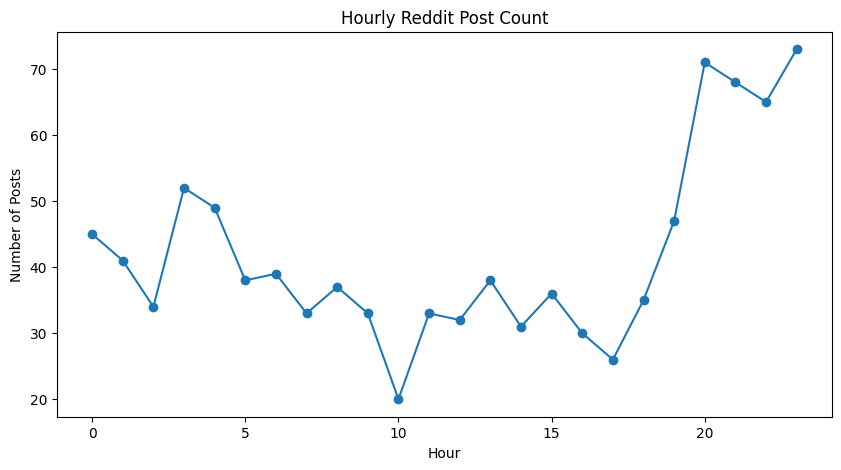

In [ ]:
#그래프로 시각화
plt.figure(figsize=(10,5))

hourly_posts.plot(kind="line", marker="o")

plt.title("Hourly Reddit Post Count")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")

plt.show()

In [ ]:
#특정 키워드 등장 횟수 계산
#ai
reddit_df["contains_ai"] = reddit_df["text_clean"].str.contains(
    r"\bAI\b",
    case=False,
    na=False,
    regex=True
)

ai_trend = reddit_df.groupby("date")["contains_ai"].sum()

print(ai_trend)

date
2025-10-15     0
2026-03-09     0
2026-03-23     0
2026-03-24     0
2026-03-25     0
2026-03-26     1
2026-03-27     0
2026-03-28     0
2026-03-29     0
2026-03-30     1
2026-03-31     0
2026-04-01     1
2026-04-02     0
2026-04-03     0
2026-04-04     0
2026-04-05     0
2026-04-06     0
2026-04-07     1
2026-04-08     1
2026-04-09     0
2026-04-10     3
2026-04-11     1
2026-04-12     0
2026-04-13     1
2026-04-14     2
2026-04-15     0
2026-04-16     1
2026-04-17     0
2026-04-18     0
2026-04-19     1
2026-04-20     1
2026-04-21     0
2026-04-22     2
2026-04-23     1
2026-04-24     1
2026-04-25     4
2026-04-26     8
2026-04-27     1
2026-04-28     3
2026-04-29     4
2026-04-30     3
2026-05-01     5
2026-05-02     9
2026-05-03    13
2026-05-04    18
2026-05-05    23
2026-05-06    24
2026-05-07    31
2026-05-08    74
Name: contains_ai, dtype: int64


## STEP7. AI 키워드 + 감성 연결 분석
>
> AI 키워드가 포함된 게시글만 따로 감성 분석한 결과입니다.
>
> **중립 65.1%, 부정 23.9%, 긍정 11.0%** 로 나타났습니다.
>
> AI 관련 게시글은 감정적으로 강한 반응보다는 뉴스, 정보 공유, 토론 성격의 중립 게시글이 많다고 해석할 수 있습니다.

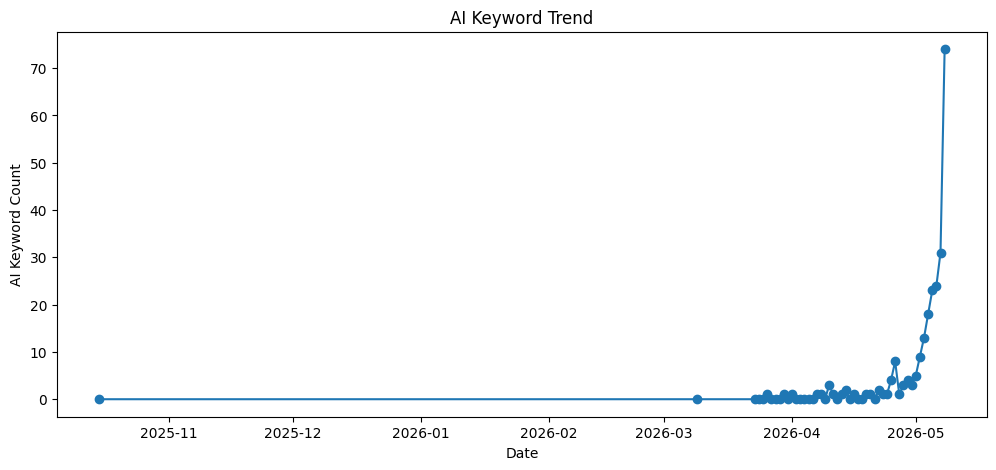

In [ ]:
#ai 키워드 트렌드 그래프
plt.figure(figsize=(12,5))

ai_trend.plot(kind="line", marker="o")

plt.title("AI Keyword Trend")
plt.xlabel("Date")
plt.ylabel("AI Keyword Count")

plt.show()

In [ ]:
#ai 키워드 비율
daily_total = reddit_df.groupby("date").size()

ai_count = reddit_df.groupby("date")["contains_ai"].sum()

ai_ratio = (ai_count / daily_total) * 100

ai_ratio

,0
date,
2025-10-15,0.000000
2026-03-09,0.000000
2026-03-23,0.000000
2026-03-24,0.000000
2026-03-25,0.000000
2026-03-26,33.333333
2026-03-27,0.000000
2026-03-28,0.000000
2026-03-29,0.000000


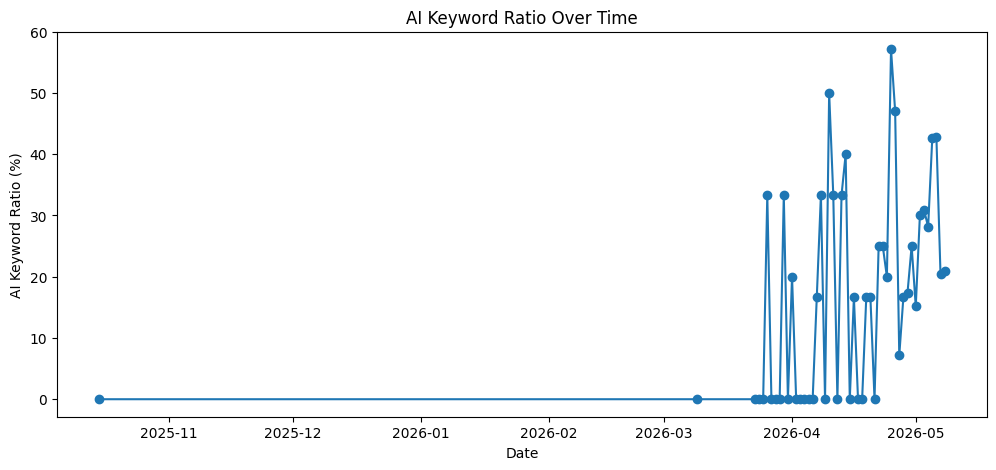

In [ ]:
#비율 그래프
plt.figure(figsize=(12,5))

ai_ratio.plot(kind="line", marker="o")

plt.title("AI Keyword Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("AI Keyword Ratio (%)")

plt.show()

In [ ]:
#여러 키워드 비교하기
keywords = {
    "ai": r"\bAI\b",
    "chatgpt": r"\bChatGPT\b",
    "openai": r"\bOpenAI\b",
    "gpu": r"\bGPU\b",
    "robot": r"\brobot\w*\b"
}

trend_result = pd.DataFrame()

for keyword, pattern in keywords.items():
    reddit_df[f"contains_{keyword}"] = reddit_df["text_clean"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )

    trend_result[keyword] = reddit_df.groupby("date")[f"contains_{keyword}"].sum()

In [ ]:
#결과 확인
trend_result

,ai,chatgpt,openai,gpu,robot
date,,,,,
2025-10-15,0,1,0,0,0
2026-03-09,0,0,0,0,0
2026-03-23,0,0,0,0,0
2026-03-24,0,0,0,0,0
2026-03-25,0,0,0,0,0
2026-03-26,1,0,0,0,0
2026-03-27,0,0,0,0,0
2026-03-28,0,0,0,0,0
2026-03-29,0,0,0,0,0


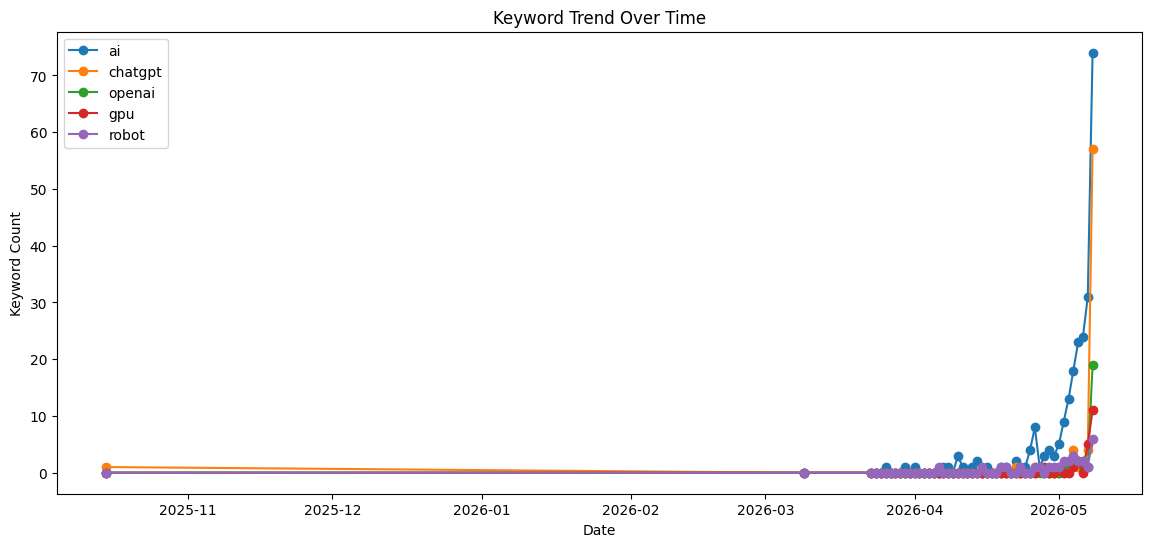

In [ ]:
#여러 키워드 그래프 그리기
plt.figure(figsize=(14,6))

for keyword in keywords:
    plt.plot(
        trend_result.index,
        trend_result[keyword],
        marker="o",
        label=keyword
    )

plt.title("Keyword Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Keyword Count")

plt.legend()

plt.show()

In [ ]:
#비율 데이터
#날짜별 전체 게시글 수
daily_total = reddit_df.groupby("date").size()

trend_ratio = pd.DataFrame()

for keyword in keywords:
  keyword_count = reddit_df.groupby("date")[f"contains_{keyword}"].sum()
  trend_ratio[keyword] = (keyword_count / daily_total) * 100

trend_ratio.head()

,ai,chatgpt,openai,gpu,robot
date,,,,,
2025-10-15,0.0,100.0,0.0,0.0,0.0
2026-03-09,0.0,0.0,0.0,0.0,0.0
2026-03-23,0.0,0.0,0.0,0.0,0.0
2026-03-24,0.0,0.0,0.0,0.0,0.0
2026-03-25,0.0,0.0,0.0,0.0,0.0


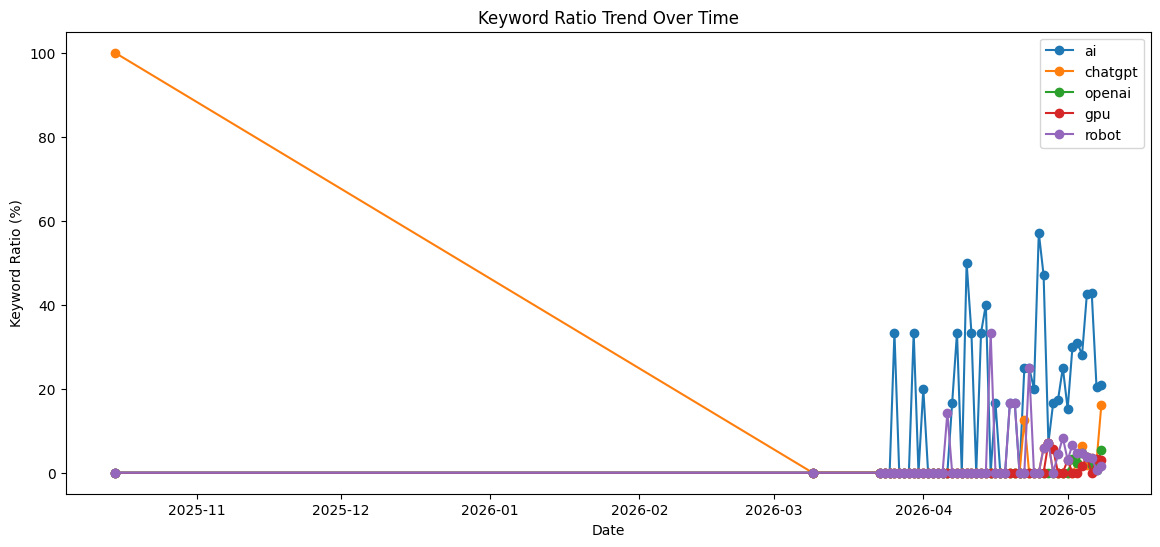

In [ ]:
#여러 키워드 비율 그래프
plt.figure(figsize=(14,6))

for keyword in trend_ratio.columns:
    plt.plot(trend_ratio.index, trend_ratio[keyword], marker="o", label=keyword)

plt.title("Keyword Ratio Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Keyword Ratio (%)")
plt.legend()
plt.show()

In [ ]:
#토픽별 게시글 수 계산
topic_trend = reddit_df.groupby(["date", "topic"]).size().unstack(fill_value=0)

topic_trend.head()

topic,-1,0,1,2,3,4,5,6,7,8,...,28,29,30,31,32,33,34,35,36,37
date,,,,,,,,,,,,,,,,,,,,,
2025-10-15,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-03-09,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-03-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-03-24,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-03-25,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


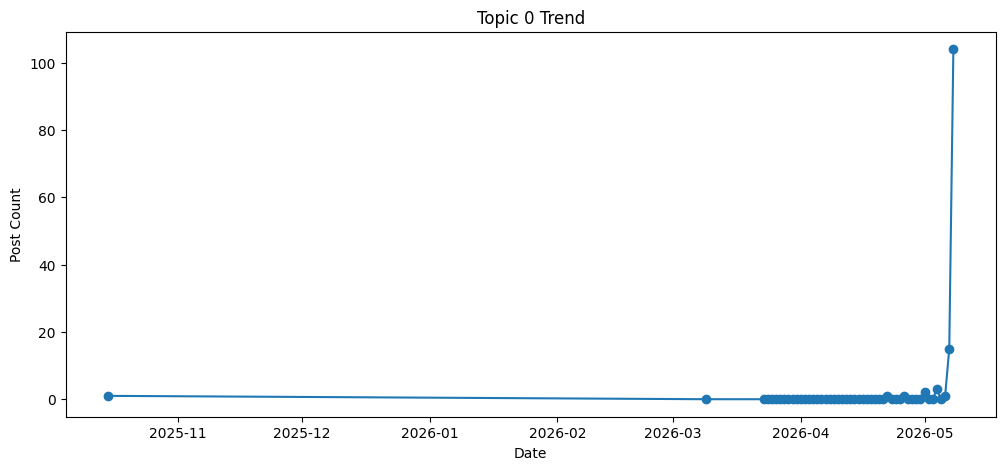

In [ ]:
#특정 토픽 그래프 보기
topic_id = 0

plt.figure(figsize=(12,5))

plt.plot(
    topic_trend.index,
    topic_trend[topic_id],
    marker="o"
)

plt.title(f"Topic {topic_id} Trend")
plt.xlabel("Date")
plt.ylabel("Post Count")

plt.show()

In [ ]:
#토픽 번호 확인하기
topic_info = pd.read_csv("reddit_topics.csv")
topic_info.head()

,topic_id,count,keywords
0,0,128,"chatgpt, image, the, it, and"
1,1,55,"the, will, we, of, is"
2,2,51,"the, model, a2, on, for"
3,3,43,"computer, laptop, to, pc, and"
4,4,38,"my, it, and, pc, have"


In [ ]:
#subreddit별 키워드 트렌드
chatgpt_posts = reddit_df[
    reddit_df["text_clean"].str.contains("chatgpt", case=False, na=False)
]

subreddit_trend = chatgpt_posts["subreddit"].value_counts()

print(subreddit_trend)

subreddit
ChatGPT            58
artificial          6
Futurology          4
datascience         2
technology          1
MachineLearning     1
programming         1
Name: count, dtype: int64


In [ ]:
#감성과 트렌드 연결하기
ai_posts = reddit_df[
    reddit_df["text_clean"].str.contains("ai", case=False, na=False)
]

ai_sentiment = ai_posts["sentiment_label"].value_counts(normalize=True)*100

print(ai_sentiment)

sentiment_label
neutral     65.102041
negative    23.877551
positive    11.020408
Name: proportion, dtype: float64


In [ ]:
#결과 csv 저장
trend_result.to_csv(
    "reddit_keyword_trend.csv",
    encoding="utf-8-sig"
)

topic_trend.to_csv(
    "reddit_topic_trend.csv",
    encoding="utf-8-sig"
)

print("트렌드 분석 결과 저장 완료")

트렌드 분석 결과 저장 완료


In [ ]:
#다운로드
files.download("reddit_keyword_trend.csv")
files.download("reddit_topic_trend.csv")
print("다운로드 완료!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 완료!


# **FAST API 배포**

---
## STEP8. FastAPI 배포 시연

 FastAPI 배포를 설명하겠습니다.
>
> 지금까지의 분석 결과를 FastAPI 서버로 제공했습니다.
>
> 마지막으로 제가 담당한 FastAPI 배포를 설명하겠습니다.
>
> 지금까지의 분석 결과를 FastAPI 서버로 제공했습니다. ngrok을 통해 외부에서 접속 가능한 URL로 연결했습니다.
>
> 총 5개의 엔드포인트를 구성했습니다.

In [ ]:
# FastAPI 패키지 설치
!pip install fastapi uvicorn pyngrok nest-asyncio -q
print("✅ 설치 완료!")

✅ 설치 완료!


In [ ]:
# 파일 업로드
# reddit_sentiment_result.csv, reddit_topics.csv, reddit_keyword_trend.csv, reddit_topic_trend.csv
from google.colab import files
uploaded = files.upload()

Saving reddit_sentiment_result.csv to reddit_sentiment_result (2).csv


In [ ]:
# CSV 불러오기
import pandas as pd

sentiment_df = pd.read_csv("reddit_sentiment_result.csv")
topic_df     = pd.read_csv("reddit_topics.csv")
keyword_trend_df = pd.read_csv("reddit_keyword_trend.csv", index_col=0)
topic_trend_df   = pd.read_csv("reddit_topic_trend.csv", index_col=0)

print("✅ 데이터 로드 완료!")
print(f"감성 분석: {len(sentiment_df)}개 서브레딧")
print(f"토픽: {len(topic_df)}개 토픽")
print(f"키워드 트렌드: {len(keyword_trend_df)}개 날짜")

✅ 데이터 로드 완료!
감성 분석: 1006개 서브레딧
토픽: 38개 토픽
키워드 트렌드: 49개 날짜


In [ ]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
import math

app = FastAPI(title="Reddit 트렌드 분석 API", version="1.0.0")

def clean_nan(data):
    """NaN 값을 None으로 변환 (JSON 직렬화 오류 방지)"""
    if isinstance(data, list):
        return [clean_nan(item) for item in data]
    if isinstance(data, dict):
        return {k: clean_nan(v) for k, v in data.items()}
    if isinstance(data, float) and math.isnan(data):
        return None
    return data

@app.get("/")
def home():
    return {"status": "running", "message": "Reddit 트렌드 분석 API 실행 중"}

@app.get("/sentiment")
def get_sentiment():
    result = clean_nan(sentiment_df.to_dict(orient="records"))
    return JSONResponse(content=result)

@app.get("/topics")
def get_topics():
    result = clean_nan(topic_df.to_dict(orient="records"))
    return JSONResponse(content=result)

@app.get("/trend/keyword")
def get_keyword_trend():
    result = clean_nan(keyword_trend_df.reset_index().to_dict(orient="records"))
    return JSONResponse(content=result)

@app.get("/trend/keyword/{keyword}")
def get_keyword_by_name(keyword: str):
    if keyword not in keyword_trend_df.columns:
        return JSONResponse(
            content={"error": f"'{keyword}' 키워드를 찾을 수 없습니다."},
            status_code=404
        )
    result = clean_nan(keyword_trend_df[[keyword]].reset_index().to_dict(orient="records"))
    return JSONResponse(content=result)

@app.get("/trend/topic")
def get_topic_trend():
    result = clean_nan(topic_trend_df.reset_index().to_dict(orient="records"))
    return JSONResponse(content=result)

print("✅ 앱 생성 완료!")

✅ 앱 생성 완료!


In [ ]:
# ngrok 토큰 입력 + 서버 실행
import uvicorn
import nest_asyncio
import threading
from pyngrok import ngrok

# ngrok.com 가입 후 토큰 복사해서 붙여넣기
ngrok.set_auth_token("3BX5SgMjGhCa7KXNsHEjNJD1yfB_2BNRsZMdLKcLyi5hkbnXB")

# 외부 접속 URL 생성
public_url = ngrok.connect(8000)
print(f"✅ API 주소: {public_url}")
print(f"✅ API 문서: {public_url}/docs  ← 이 주소로 접속!")

# 서버 백그라운드 실행
nest_asyncio.apply()

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

✅ API 주소: NgrokTunnel: "https://hadlee-isocyano-photomechanically.ngrok-free.dev" -> "http://localhost:8000"
✅ API 문서: NgrokTunnel: "https://hadlee-isocyano-photomechanically.ngrok-free.dev" -> "http://localhost:8000"/docs  ← 이 주소로 접속!


In [ ]:
print("=" * 55)
print("   Reddit 데이터를 활용한 AI 기술 트렌드 분석")
print("   최종 결과 요약")
print("=" * 55)

print("\n📊 데이터")
print("  · 수집 게시글 : 1,006개")
print("  · 서브레딧    : 10개 (ChatGPT, AI, technology 등)")

print("\n🧠 감성 분석 (RoBERTa)")
print("  · Neutral  : 61.4%")
print("  · Negative : 24.8%")
print("  · Positive : 13.8%")
print("  → AI 게시글은 중립적 정보 공유 성격이 강함")

print("\n🗂️ 토픽 모델링 (BERTopic)")
print("  · 발견된 토픽  : 36개")
print("  · 최대 토픽    : chatgpt, image 관련 (129개)")
print("  · 상위 토픽    : ChatGPT, AI, OpenAI 중심")

print("\n📈 트렌드 분석")
print("  · AI 키워드 최고치 : 2026-05-08 (74회)")
print("  · 키워드 순위      : AI > ChatGPT > OpenAI > GPU > Robot")
print("  · 활발한 시간대    : 20시 ~ 23시")

print("\n🚀 FastAPI 배포")
print("  · 엔드포인트 : 5개")
print("  · 시연 주소  : /docs")

print("\n" + "=" * 55)
print(" ")
print("=" * 55)

   Reddit 데이터를 활용한 AI 기술 트렌드 분석
   최종 결과 요약

📊 데이터
  · 수집 게시글 : 1,006개
  · 서브레딧    : 10개 (ChatGPT, AI, technology 등)

🧠 감성 분석 (RoBERTa)
  · Neutral  : 61.4%
  · Negative : 24.8%
  · Positive : 13.8%
  → AI 게시글은 중립적 정보 공유 성격이 강함

🗂️ 토픽 모델링 (BERTopic)
  · 발견된 토픽  : 36개
  · 최대 토픽    : chatgpt, image 관련 (129개)
  · 상위 토픽    : ChatGPT, AI, OpenAI 중심

📈 트렌드 분석
  · AI 키워드 최고치 : 2026-05-08 (74회)
  · 키워드 순위      : AI > ChatGPT > OpenAI > GPU > Robot
  · 활발한 시간대    : 20시 ~ 23시

🚀 FastAPI 배포
  · 엔드포인트 : 5개
  · 시연 주소  : /docs

 


---
## STEP9. 결론 및 한계점

>
> **확인한 인사이트**  
> - Reddit 기술 커뮤니티에서 AI 관련 키워드는 4월 말부터 급격히 증가했고, 5월 8일에 최고치를 기록했습니다.  
> - 커뮤니티 감성은 중립이 주를 이루지만 부정적 시각도 상당히 존재하며, 이는 AI에 대한 기대와 우려가 공존하고 있음을 보여줍니다.  
> - BERTopic으로 36개 토픽을 자동 발견했고, ChatGPT 이미지 관련 토픽이 가장 많이 논의됐습니다.  
>
> **한계점**  
> - 수집 기간이 짧고 데이터 수가 1,006개로 제한적입니다.  
> - Reddit 신규 계정 제한으로 공식 API 대신 JSON 방식으로 수집했습니다.  
>
> **향후 계획**  
> - 더 많은 서브레딧과 긴 기간의 데이터로 트렌드 예측 모델로 발전시킬 수 있습니다.  
>

In [ ]:
# import requests

# # NgrokTunnel 객체에서 실제 URL 문자열 추출
# base_url = public_url.public_url
# print("접속 주소:", base_url)

# # 상태 확인
# print("\n상태:", requests.get(f"{base_url}/").json())

# # 감성 결과 첫 번째
# print("\n감성 분석:", requests.get(f"{base_url}/sentiment").json()[0])

# # AI 트렌드 마지막 3일
# print("\nAI 트렌드:", requests.get(f"{base_url}/trend/keyword/ai").json()[-3:])